In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc
import scipy
from itertools import combinations
import pycwt
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import mixture
import statistics

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

datadir = "/jukebox/hasson/snastase/social-ctf/results"
lstmsNew = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

In [57]:
pc=0
lstmDiffs=abs(lstmsNew[..., pc][0]-lstmsNew[..., pc][1])
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))


gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

print(gmm.means_)
print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

print(gmm2.means_)
print(gmm2.weights_)
print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

(4501,)
10.504830653233267
[[6.63147263]]
[[[10.50366369]]]
33960.329267199304
-3.7706626480174092
---
[[27.78982889]
 [ 1.73242727]]
[0.18800974 0.81199026]
[[[5.31316864]]

 [[1.29595349]]]
21876.590442260425
-2.4255199031208576


(array([3245.,  403.,   20.,   23.,   16.,   26.,   66.,  143.,  286.,
         273.]),
 array([1.19171220e-03, 3.43204498e+00, 6.86289826e+00, 1.02937515e+01,
        1.37246048e+01, 1.71554581e+01, 2.05863113e+01, 2.40171646e+01,
        2.74480179e+01, 3.08788712e+01, 3.43097244e+01]),
 <BarContainer object of 10 artists>)

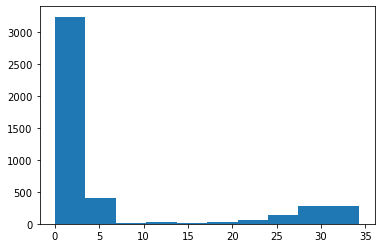

In [13]:
plt.hist(lstmDiffs)

In [14]:
pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))
#print("gmm2: rand index: ", sklearn.metrics.rand_score(lstmDiffs, pred)) #consensus measure, 1 is good
#print("gmm2: adjusted rand index: ", sklearn.metrics.adjusted_rand_score(lstmDiffs, pred)) # 0 to 1
#print("gmm2: adj mutual info score: ", sklearn.metrics.adjusted_mutual_info_score(lstmDiffs, pred)) #consensus measure, 1 is good

gmm2: silhouttte:  0.9083073707522531


(4501,)
3.7246986174289956
[[4.92080856]]
[3.72428497]
24626.61211080297
-2.7338133749229483
---
[[2.65775957]
 [8.18195413]]
[0.59033865 0.40966135]
[1.7783051  3.35941326]
23758.16840994062
-2.6345376733586043
gmm2: silhouttte:  0.6120946883641122


(array([1206., 1065.,  795.,  622.,  393.,  223.,  107.,   65.,   19.,
           6.]),
 array([5.01316969e-05, 2.07808476e+00, 4.15611940e+00, 6.23415403e+00,
        8.31218866e+00, 1.03902233e+01, 1.24682579e+01, 1.45462926e+01,
        1.66243272e+01, 1.87023618e+01, 2.07803965e+01]),
 <BarContainer object of 10 artists>)

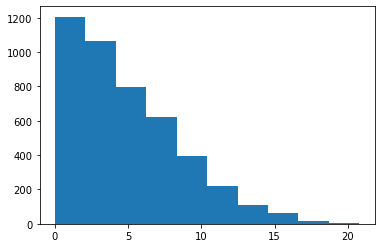

In [56]:
pc=3
lstmDiffs=abs(lstmsNew[..., pc][0]-lstmsNew[..., pc][1])
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))


gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='spherical')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

print(gmm.means_)
print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='spherical')
gmm2 = gmm2.fit(lstmDiffs)

print(gmm2.means_)
print(gmm2.weights_)
print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

(4501,)
4.666482528951537
[[6.19741756]]
[[[4.66596422]]]
---
[[ 3.34042183]
 [10.22940362]]
[0.58528041 0.41471959]
[[[2.15444466]]

 [[4.26255589]]]
gmm2: silhouttte:  0.612491423229653


(array([1339., 1136.,  838.,  594.,  316.,  172.,   74.,   21.,    7.,
           4.]),
 array([8.26089724e-04, 2.91825962e+00, 5.83569315e+00, 8.75312668e+00,
        1.16705602e+01, 1.45879937e+01, 1.75054273e+01, 2.04228608e+01,
        2.33402943e+01, 2.62577279e+01, 2.91751614e+01]),
 <BarContainer object of 10 artists>)

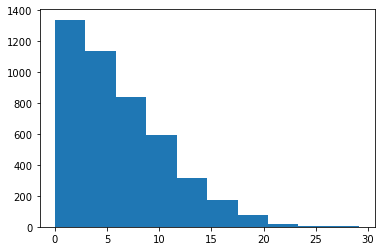

In [16]:
pc=2
lstmDiffs=abs(lstmsNew[..., pc][0]-lstmsNew[..., pc][1])
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))


gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

print(gmm.means_)
print(np.sqrt(gmm.covariances_))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

print(gmm2.means_)
print(gmm2.weights_)
print(np.sqrt(gmm2.covariances_))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

(4501,)
5.560435029466104
[[7.11594263]]
[[[5.5598174]]]
28233.62715845078
-3.134503782348833
---
[[ 3.81465051]
 [12.40069736]]
[0.615505 0.384495]
[[[2.52863473]]

 [[4.97840308]]]
27119.431422068374
-3.007928365663398
gmm2: silhouttte:  0.6253772834785276


(array([1167.,  980.,  782.,  562.,  393.,  286.,  160.,   90.,   60.,
          21.]),
 array([4.63460479e-04, 2.74959168e+00, 5.49871990e+00, 8.24784812e+00,
        1.09969763e+01, 1.37461046e+01, 1.64952328e+01, 1.92443610e+01,
        2.19934892e+01, 2.47426174e+01, 2.74917457e+01]),
 <BarContainer object of 10 artists>)

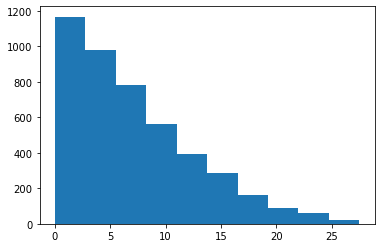

In [65]:
pc=1
lstmDiffs=abs(lstmsNew[..., pc][0]-lstmsNew[..., pc][1])
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))


gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

print(gmm.means_)
print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

print(gmm2.means_)
print(gmm2.weights_)
print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

In [33]:
pc=0
isc=window_isc(lstmsNew[..., pc].T)[:,0]
print(isc.shape)
print('std dev:',np.std(isc))
print('max:',np.max(isc))
print('range:',np.max(isc)-np.min(isc))

pc=3
isc=window_isc(lstmsNew[..., pc].T)[:,0]
print(isc.shape)
print('std dev:',np.std(isc))
print('max:',np.max(isc))
print('range:',np.max(isc)-np.min(isc))

pc=4
isc=window_isc(lstmsNew[..., pc].T)[:,0]
print(isc.shape)
print('std dev:',np.std(isc))
print('max:',np.max(isc))
print('range:',np.max(isc)-np.min(isc))

pc=6
isc=window_isc(lstmsNew[..., pc].T)[:,0]
print(isc.shape)
print('std dev:',np.std(isc))
print('max:',np.max(isc))
print('range:',np.max(isc)-np.min(isc))

Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows
(4351,)
std dev: 0.3280805000588406
max: 0.8924797439739641
range: 1.6016831389088633
Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows
(4351,)
std dev: 0.2946329877374177
max: 0.6076456437518971
range: 1.4199300098156344
Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500

In [49]:
#lstmsNew1 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 
#lstmsNew2 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

pc=0
x = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc][0][:,np.newaxis]
for map in range(25):
    for repeat in range(31):
        if map!=0 and repeat!=0:
            t = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc][0][:,np.newaxis]
            x = np.concatenate((x, t), axis=1)
y = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy')[..., pc][0]

model = sklearn.linear_model.LinearRegression().fit(x, y)
r_sq = model.score(x, y)
print(f'r sq: {r_sq}')

r sq: 0.9610512078668224


In [ ]:
# start with 3 maps and 8 repeats
# sklearn group kfold, predefined split

In [75]:
pc=1

temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
lstmDiffs = abs(temp[0] - temp[1])
for map in range(3):
    for repeat in range(8):
        if map!=0 and repeat!=0:
            temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]
            t = abs(temp[0] - temp[1])
            lstmDiffs = np.concatenate((lstmDiffs, t))
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))

gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

(67515,)
5.420991771216199


419858.8543195679
-3.109209909719463
---
Weights: [0.60008365 0.39991635]
406679.27109609253
-3.011357998746357
gmm2: silhouttte:  0.6143195263150851


(array([1.8381e+04, 1.5888e+04, 1.2390e+04, 8.9680e+03, 5.9980e+03,
        3.4390e+03, 1.6640e+03, 6.1100e+02, 1.6300e+02, 1.3000e+01]),
 array([6.42189667e-05, 3.13308933e+00, 6.26611443e+00, 9.39913954e+00,
        1.25321647e+01, 1.56651898e+01, 1.87982149e+01, 2.19312400e+01,
        2.50642651e+01, 2.81972902e+01, 3.13303153e+01]),
 <BarContainer object of 10 artists>)

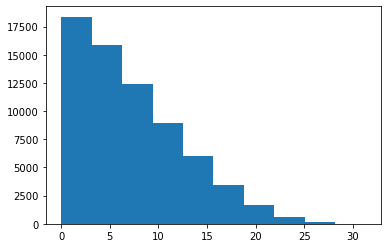

In [76]:
#print(gmm.means_)
#print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

#print(gmm2.means_)
print('Weights:', gmm2.weights_)
#print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

In [77]:
pc=0

temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
lstmDiffs = abs(temp[0] - temp[1])
for map in range(3):
    for repeat in range(8):
        if map!=0 and repeat!=0:
            temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]
            t = abs(temp[0] - temp[1])
            lstmDiffs = np.concatenate((lstmDiffs, t))
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))

gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

(67515,)
10.332406921598412


506954.0788708169
-3.7542163864375926
---
Weights: [0.83509636 0.16490364]
323516.4788028096
-2.3954741781636497
gmm2: silhouttte:  0.913827043211982


(array([51986.,  4399.,   240.,   241.,   327.,   700.,  1754.,  4678.,
         2988.,   202.]),
 array([1.97449464e-05, 3.97821532e+00, 7.95641090e+00, 1.19346065e+01,
        1.59128021e+01, 1.98909976e+01, 2.38691932e+01, 2.78473888e+01,
        3.18255844e+01, 3.58037800e+01, 3.97819755e+01]),
 <BarContainer object of 10 artists>)

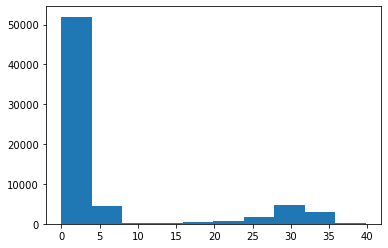

In [78]:
#print(gmm.means_)
#print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

#print(gmm2.means_)
print('Weights:', gmm2.weights_)
#print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

In [79]:
pc=3

temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
lstmDiffs = abs(temp[0] - temp[1])
for map in range(3):
    for repeat in range(8):
        if map!=0 and repeat!=0:
            temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]
            t = abs(temp[0] - temp[1])
            lstmDiffs = np.concatenate((lstmDiffs, t))
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))

gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

(67515,)
3.9002484844737864


375401.7773342569
-2.7799713924617353
---
Weights: [0.63805455 0.36194545]
360770.65269748145
-2.6713697117093202
gmm2: silhouttte:  0.6194253943007421


(array([19446., 16521., 12578.,  8397.,  5209.,  3049.,  1560.,   573.,
          162.,    20.]),
 array([4.22061445e-05, 2.29553886e+00, 4.59103551e+00, 6.88653216e+00,
        9.18202881e+00, 1.14775255e+01, 1.37730221e+01, 1.60685188e+01,
        1.83640154e+01, 2.06595121e+01, 2.29550087e+01]),
 <BarContainer object of 10 artists>)

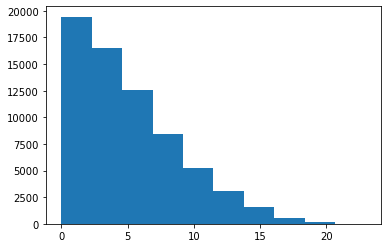

In [80]:
#print(gmm.means_)
#print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

#print(gmm2.means_)
print('Weights:', gmm2.weights_)
#print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)

In [81]:
pc=6

temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
lstmDiffs = abs(temp[0] - temp[1])
for map in range(3):
    for repeat in range(8):
        if map!=0 and repeat!=0:
            temp = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]
            t = abs(temp[0] - temp[1])
            lstmDiffs = np.concatenate((lstmDiffs, t))
print(lstmDiffs.shape)
print(np.sqrt(statistics.variance(lstmDiffs)))

gmm = sklearn.mixture.GaussianMixture(n_components=1, covariance_type='full')
lstmDiffs = lstmDiffs.reshape(-1, 1)
gmm = gmm.fit(lstmDiffs)

(67515,)
2.1704033598126213


296257.01683314884
-2.1938441577649415
---
Weights: [0.36366298 0.63633702]
282779.300758056
-2.0937843459430057
gmm2: silhouttte:  0.6134768088797082


(array([2.1303e+04, 1.8295e+04, 1.2990e+04, 7.7990e+03, 4.1640e+03,
        1.9680e+03, 7.8500e+02, 1.7000e+02, 3.6000e+01, 5.0000e+00]),
 array([4.61093967e-05, 1.46673782e+00, 2.93342953e+00, 4.40012123e+00,
        5.86681294e+00, 7.33350465e+00, 8.80019636e+00, 1.02668881e+01,
        1.17335798e+01, 1.32002715e+01, 1.46669632e+01]),
 <BarContainer object of 10 artists>)

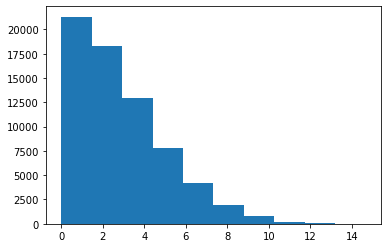

In [82]:
#print(gmm.means_)
#print(np.sqrt(gmm.covariances_))
print(gmm.bic(lstmDiffs))
print(gmm.score(lstmDiffs))
print('---')


gmm2 = sklearn.mixture.GaussianMixture(n_components=2, covariance_type='full')
gmm2 = gmm2.fit(lstmDiffs)

#print(gmm2.means_)
print('Weights:', gmm2.weights_)
#print(np.sqrt(gmm2.covariances_))
print(gmm2.bic(lstmDiffs))
print(gmm2.score(lstmDiffs))

pred = gmm2.predict(lstmDiffs)
print("gmm2: silhouttte: ", sklearn.metrics.silhouette_score(lstmDiffs, pred))

plt.hist(lstmDiffs)